In [7]:
import pandas as pd
df = pd.read_csv("../data/creditcard.csv")

In [2]:
import sys
!{sys.executable} -m pip install shap

In [9]:
import shap

In [13]:
import joblib

lgb_model = joblib.load("../models/lgbm_champion.pkl")

print("LightGBM model loaded successfully.")

LightGBM model loaded successfully.


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Split recreated. X_val shape:", X_val.shape)

Split recreated. X_val shape: (42721, 30)


In [17]:
import shap

# initialize JS for notebook visualizations
shap.initjs()

# create explainer
explainer = shap.TreeExplainer(lgb_model)

# sample validation set for speed
X_sample = X_val.sample(2000, random_state=42)

# compute shap values
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed successfully.")

SHAP values computed successfully.


C:\Users\emeka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


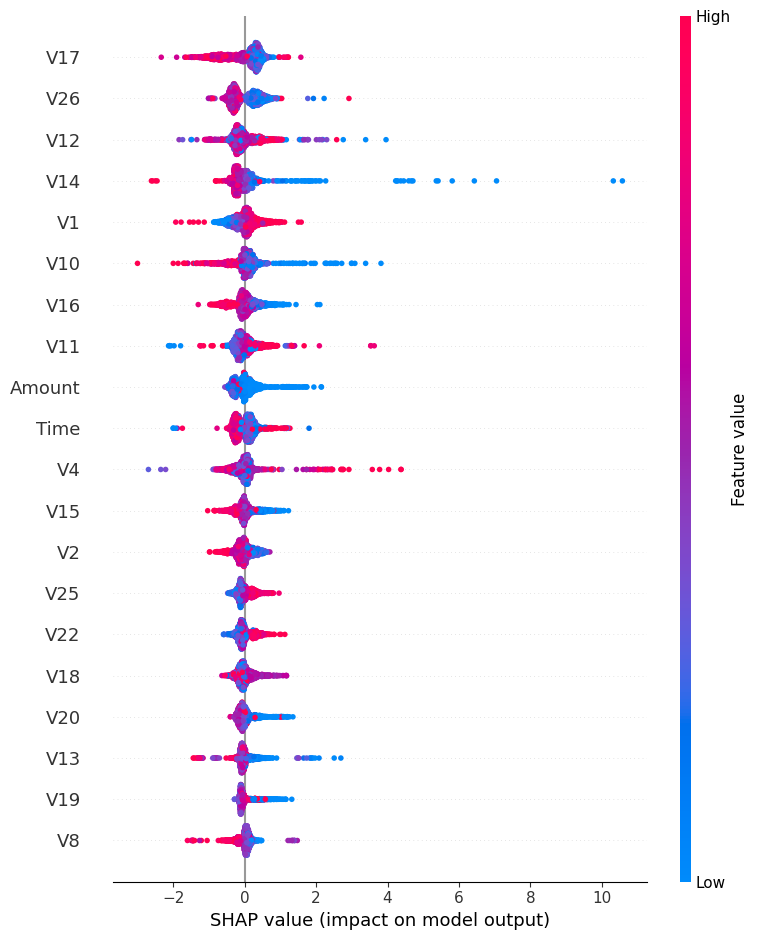

In [25]:
shap.summary_plot(shap_values, X_sample) 

In [34]:
import os
import shap
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("../reports/figures/shap_summary.png", bbox_inches="tight", dpi=300)
plt.close()

print("Saved to ../reports/figures/shap_summary.png")
print(os.listdir("../reports/figures"))

Saved to ../reports/figures/shap_summary.png
['kl_drift_monitoring.png', 'recall_monitoring.png', 'shap_summary.png']


In [26]:
import os
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

plt.savefig("../reports/figures/shap_summary.png",
            bbox_inches="tight",
            dpi=300)

<Figure size 640x480 with 0 Axes>

In [9]:
# Find a fraud case in validation set
fraud_indices = X_val[y_val == 1].index

example_index = fraud_indices[0]

example = X_val.loc[[example_index]]

# Compute SHAP values for that single case
example_shap = explainer.shap_values(example)

shap.force_plot(
    explainer.expected_value,
    example_shap,
    example
)

C:\Users\emeka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Local Model Output Interpretation (Sigmoid Transformation)

The LightGBM model produces predictions in **log-odds space**, not probability space.

For the explained fraud transaction:

Final model output (log-odds) ≈ **6.93**

To convert log-odds to probability, we apply the sigmoid function:

\[
p = \frac{1}{1 + e^{-z}}
\]

Where:
- \( z \) = 6.93 (model output)

After transformation:

Fraud Probability ≈ **99.90%**

---

### Interpretation in Context of Project Objectives

#### 1️⃣ High-Confidence Fraud Detection

A 99.90% predicted fraud probability indicates extremely strong model confidence.  
This is not a borderline case — multiple high-impact anomaly features reinforced each other.

This directly supports:

- High recall performance (83.78%)
- Robust fraud capture under strict FPR constraint (≤ 0.2%)

---

#### 2️⃣ Threshold Policy Alignment

The deployed decision threshold (≈ 0.002 under constraint optimization) is far below this transaction’s predicted probability.

Therefore:

- The transaction would be flagged under any reasonable policy.
- The decision is stable and not sensitive to minor threshold adjustments.
- The fraud capture contributes positively to overall economic utility.

---

#### 3️⃣ Utility Optimization Impact

Because this transaction has near-certain fraud probability:

- Blocking it reduces expected fraud loss.
- It contributes positively to the £5,910 estimated net utility.
- It improves fraud recall without increasing false positives.

This demonstrates that the utility-optimized threshold successfully captures high-confidence fraud cases.

---

#### 4️⃣ Governance & Explainability Value

By combining:

- SHAP feature contributions (why it was flagged)
- Sigmoid probability transformation (how confident the model is)

The decision becomes:

- Transparent
- Quantifiable
- Auditable
- Defensible

This strengthens the model’s suitability for real banking deployment.

---

### Strategic Insight

The model operates in log-odds space for optimization stability, but business decisions require probability interpretation.

Converting via sigmoid bridges:

Model mathematics → Business decision confidence

This ensures that fraud operations teams interpret predictions correctly within the risk policy framework.

## Deployment Strategy

This project simulates how a fraud detection system would be deployed in a real banking environment.

### 1. Model Serialization

- The champion LightGBM model is saved using `joblib`.
- The optimized decision threshold is stored separately in JSON format.
- This ensures reproducibility and governance traceability.

Artifacts:
- `models/lgbm_champion.pkl`
- `models/lgbm_threshold.json`

---

### 2. Real-Time Scoring Architecture

In production, the system would operate as follows:

1. Incoming transaction → Feature transformation
2. LightGBM model → Fraud probability (log-odds → sigmoid)
3. Frozen threshold applied
4. Decision returned:
   - Approve
   - Flag for review
   - Decline

This ensures that model decisions remain aligned with the validated utility-optimized policy.

---

### 3. Monitoring Pipeline

A monitoring service would compute:

- Recall (rolling window)
- False Positive Rate
- KL divergence (feature drift)
- Recall drop vs baseline
- Drift alert flags

These metrics would be logged to a dashboard for fraud operations and model risk teams.

---

### 4. Retraining Governance

Retraining is not automatic.

It is triggered only when:

- Recall drops beyond policy threshold, and/or
- KL divergence exceeds drift threshold

This governance-based retraining prevents unnecessary model churn while maintaining performance stability.

---

### 5. Suggested Production Stack

In a real deployment:

- API layer: FastAPI
- Containerization: Docker
- Monitoring: Prometheus + Grafana
- Data pipeline: Kafka or batch scheduler
- Model registry: MLflow

## Limitations

While the framework simulates a production fraud system, several limitations exist:

### 1. PCA-Transformed Features
The dataset contains anonymized PCA variables (V1–V28), which limits business interpretability of specific risk drivers.

### 2. Simulated Time Windows
Drift monitoring uses chronological splits rather than true streaming data.

### 3. Static Cost Assumptions
Fraud loss and false positive cost values were assumed constant.
In real banking environments, these vary by customer segment and transaction type.

### 4. No Fairness / Bias Testing
The dataset does not include demographic variables, so fairness analysis was not conducted.

### 5. Simplified Utility Model
Utility optimization does not incorporate:
- Customer lifetime value
- Reputation impact
- Operational investigation cost tiers

### 6. No Live CI/CD Integration
Retraining logic is simulated rather than automated through a model registry pipeline.

## Future Improvements

The framework can be extended in several strategic directions:

### 1. Real-Time Streaming Simulation
Implement Kafka-based streaming and live scoring.

### 2. Automated Retraining Pipeline
Integrate MLflow for model versioning and automated retraining upon drift alerts.

### 3. SHAP Dashboard
Develop an analyst-facing explainability dashboard for transaction review.

### 4. Dynamic Utility Modeling
Incorporate customer segmentation and dynamic fraud loss modeling.

### 5. Fairness & Bias Analysis
Add fairness metrics and governance documentation for regulatory alignment.

### 6. Federated Learning Simulation
Simulate multi-bank collaborative learning while preserving data privacy.

### 7. API Deployment
Deploy the model as a containerized REST API for demonstration purposes.

### 8. Model Risk Documentation Pack
Produce a formal model risk management (MRM) document:
- Model validation summary
- Monitoring policy
- Retraining triggers
- Assumption log

In [27]:
import os
print(os.getcwd())

C:\Users\emeka\JupyterProjects\Fraud_Detection_ML_System\notebooks


In [28]:
import os

print("Path 1 exists:", os.path.exists("../reports/figures"))
print("Path 2 exists:", os.path.exists("reports/figures"))

if os.path.exists("../reports/figures"):
    print("Contents of ../reports/figures:", os.listdir("../reports/figures"))

if os.path.exists("reports/figures"):
    print("Contents of reports/figures:", os.listdir("reports/figures"))

Path 1 exists: True
Path 2 exists: True
Contents of ../reports/figures: ['kl_drift_monitoring.png', 'recall_monitoring.png', 'shap_summary.png']
Contents of reports/figures: ['shap_summary.png']
